# Скрытые слои в LLMs




Модель - distilgpt2 (82M параметров, 6 трансформерных блоков)

Корпус - SST-2 (Stanford Sentiment Treebank) — бинарная классификация тональности.

In [ ]:
!pip install transformers datasets scikit-learn matplotlib seaborn umap-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import GPT2Model, GPT2Tokenizer
from datasets import load_dataset

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy
from tqdm.auto import tqdm
import gc

import umap
UMAP_AVAILABLE = True


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
MODEL_NAME = 'distilgpt2'

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2Model.from_pretrained(MODEL_NAME, output_hidden_states=True)
model = model.to(device)
model.eval()

n_layers    = model.config.n_layer
hidden_size = model.config.n_embd
n_heads     = model.config.n_head

print(f"\nАрхитектура {MODEL_NAME}:")
print(f"  Трансформерных блоков: {n_layers}")
print(f"  Размер скрытого состояния: {hidden_size}")
print(f"  Голов внимания: {n_heads}")
print(f"  Всего слоёв для пробинга: {n_layers + 1} (embedding + {n_layers} блоков)")
print(f"  Параметров: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Архитектура distilgpt2:
  Трансформерных блоков: 6
  Размер скрытого состояния: 768
  Голов внимания: 12
  Всего слоёв для пробинга: 7 (embedding + 6 блоков)
  Параметров: 81.9M


In [ ]:
dataset = load_dataset('glue', 'sst2')
N_TRAIN, N_TEST = 1500, 500

train_data = dataset['train'].shuffle(seed=SEED).select(range(N_TRAIN))
test_data  = dataset['validation'].shuffle(seed=SEED).select(range(N_TEST))

train_texts  = list(train_data['sentence'])
train_labels = np.array(train_data['label'])
test_texts   = list(test_data['sentence'])
test_labels  = np.array(test_data['label'])

print(f"Train: {len(train_texts)} | Test: {len(test_texts)}")
print(f"Баланс (train): {train_labels.mean():.1%} positive")
print("\nПримеры:")
for i in range(len(train_labels)-1, len(train_labels)-4,-1):
    tag = 'POS' if train_labels[i] == 1 else 'NEG'
    print(f"  [{tag}] {train_texts[i][:80]}")


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 1500 | Test: 500
Баланс (train): 56.1% positive

Примеры:
  [NEG] joyless , idiotic , annoying , heavy-handed , visually atrocious , and often dow
  [POS] a slick , engrossing melodrama . 
  [POS] since the empire strikes back ... a majestic achievement , an epic of astonishin


In [ ]:
def extract_hidden_states(texts, batch_size=32, max_length=64):
    all_layers = [[] for _ in range(n_layers + 1)]

    for i in tqdm(range(0, len(texts), batch_size), desc="->"):
        batch = texts[i : i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model(**enc)

        last_idx = enc['attention_mask'].sum(dim=1) - 1
        batch_idx = torch.arange(last_idx.size(0), device=device)

        for layer_idx, hs in enumerate(out.hidden_states):
            vec = hs[batch_idx, last_idx, :].cpu().float().numpy()
            all_layers[layer_idx].append(vec)

        del enc, out
        torch.cuda.empty_cache()

    return [np.concatenate(l, axis=0) for l in all_layers]


print("Train")
train_hidden = extract_hidden_states(train_texts)
print("Test")
test_hidden  = extract_hidden_states(test_texts)

layer_names = ['Embedding'] + [f'Block {i}' for i in range(1, n_layers + 1)]
print(f"\nГотово! Слоёв: {len(train_hidden)}, форма: {train_hidden[0].shape}")


Train


->:   0%|          | 0/47 [00:00<?, ?it/s]

Test


->:   0%|          | 0/16 [00:00<?, ?it/s]


Готово! Слоёв: 7, форма: (1500, 768)


Две метрики.

Первая идейно -- чем дальше центры классов друг от друга и чем «кучнее» вокруг центров —> тем лучше линейная разделимость. (LSS)
Вторая идейно -- измеряет, насколько отличаются «формы» распределений двух классов, проверка на неоднородность (LES)

In [30]:
def linear_separability_score(X, y, n_components=50):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    pca = PCA(n_components=min(n_components, X_s.shape[1], X_s.shape[0]-1), random_state=SEED)
    X_p = pca.fit_transform(X_s)
    c0, c1 = X_p[y==0].mean(0), X_p[y==1].mean(0)
    s0, s1 = X_p[y==0].std(0).mean(), X_p[y==1].std(0).mean()
    return np.linalg.norm(c0 - c1) / (s0 + s1 + 1e-8)

def layer_entropy_score(X, y, n_components=20):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    pca = PCA(n_components=min(n_components, X_s.shape[1], X_s.shape[0]-1), random_state=SEED)
    X_p = pca.fit_transform(X_s)
    v0 = X_p[y==0].var(0) + 1e-8
    v1 = X_p[y==1].var(0) + 1e-8
    return 0.5 * np.mean(v0/v1 + v1/v0 - 2)

LR на каждом слое. cv= 7

In [ ]:
results = []
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=SEED)

print(f"{'Слой':<15} {'CV Acc':>8} {'CV F1':>8} {'Test Acc':>10} {'Test AUC':>10} {'LSS':>8} {'LES':>8}")

for layer_idx in range(n_layers + 1):
    X_train = train_hidden[layer_idx]
    X_test  = test_hidden[layer_idx]

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED))
    ])

    cv_acc = cross_val_score(clf, X_train, train_labels, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1  = cross_val_score(clf, X_train, train_labels, cv=cv, scoring='f1',       n_jobs=-1)

    clf.fit(X_train, train_labels)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    test_acc = accuracy_score(test_labels, y_pred)
    test_f1  = f1_score(test_labels, y_pred)
    test_auc = roc_auc_score(test_labels, y_proba)
    lss      = linear_separability_score(X_train, train_labels)
    les      = layer_entropy_score(X_train, train_labels)

    results.append({
        'layer_idx': layer_idx, 'layer_name': layer_names[layer_idx],
        'cv_acc_mean': cv_acc.mean(), 'cv_acc_std': cv_acc.std(),
        'cv_f1_mean':  cv_f1.mean(),  'cv_f1_std':  cv_f1.std(),
        'test_acc': test_acc, 'test_f1': test_f1, 'test_auc': test_auc,
        'lss': lss, 'les': les, 'clf': clf
    })

    print(f"{layer_names[layer_idx]:<15} {cv_acc.mean():>8.4f} {cv_f1.mean():>8.4f} "
          f"{test_acc:>10.4f} {test_auc:>10.4f} {lss:>8.3f} {les:>8.3f}")

df = pd.DataFrame(results).drop(columns=['clf'])


Слой              CV Acc    CV F1   Test Acc   Test AUC      LSS      LES
Embedding         0.5520   0.6667     0.4860     0.4681    0.936    0.027
Block 1           0.6840   0.7237     0.6920     0.7625    0.668    0.004
Block 2           0.6540   0.6911     0.6900     0.7541    0.578    0.004
Block 3           0.6733   0.7119     0.7240     0.8030    0.563    0.006
Block 4           0.7100   0.7406     0.7600     0.8398    0.620    0.011
Block 5           0.6993   0.7350     0.7880     0.8533    0.699    0.005
Block 6           0.7053   0.7368     0.7660     0.8372    0.784    0.006


In [ ]:
def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

df['composite'] = (
    minmax(df['test_acc'].values) +
    minmax(df['test_auc'].values) +
    minmax(df['cv_acc_mean'].values) +
    minmax(df['lss'].values) +
    minmax(df['les'].values)
) / 5

display_df = df[['layer_name','test_acc','test_f1','test_auc','lss','les','composite']].copy()
display_df.columns = ['Слой','Test Acc','Test F1','AUC-ROC','LSS','LES','Composite']
display(display_df.style
    .background_gradient(subset=['Test Acc','AUC-ROC','LSS','Composite'])
    .format('{:.4f}', subset=['Test Acc','Test F1','AUC-ROC','LSS','LES','Composite']))

best = df.loc[df['composite'].idxmax()]
print(f"\nЛучший слой: {best['layer_name']},  Test Acc={best['test_acc']:.4f},  AUC={best['test_auc']:.4f}")


,Слой,Test Acc,Test F1,AUC-ROC,LSS,LES,Composite
0,Embedding,0.4860,0.5369,0.4681,0.9364,0.0272,0.4000
1,Block 1,0.6920,0.6992,0.7625,0.6684,0.0041,0.5136
2,Block 2,0.6900,0.7059,0.7541,0.5780,0.0040,0.4208
3,Block 3,0.7240,0.7444,0.8030,0.5629,0.0056,0.4986
4,Block 4,0.7600,0.7810,0.8398,0.6203,0.0108,0.6638
5,Block 5,0.7880,0.8015,0.8533,0.6995,0.0049,0.6672
6,Block 6,0.7660,0.7788,0.8372,0.7841,0.0062,0.7084



Лучший слой: Block 6,  Test Acc=0.7660,  AUC=0.8372


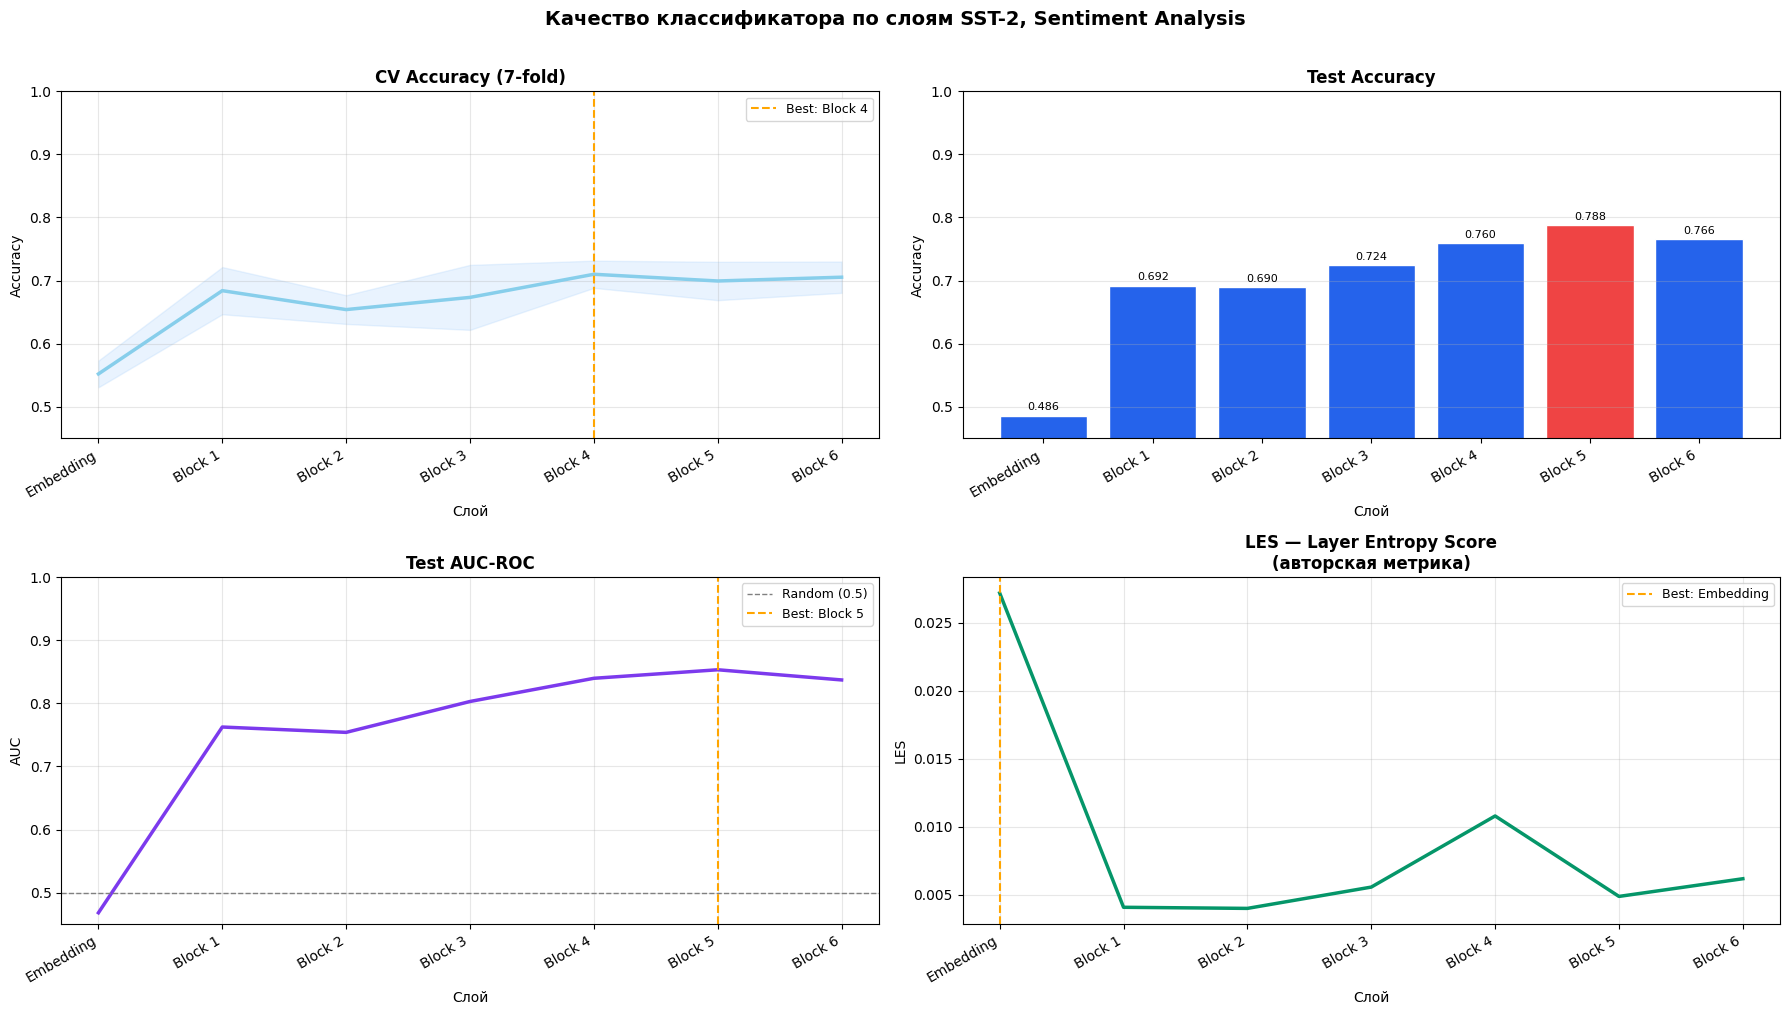

In [28]:
layer_indices = df['layer_idx'].values
layer_lbl     = df['layer_name'].values

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Качество классификатора по слоям SST-2, Sentiment Analysis',
             fontsize=14, fontweight='bold', y=1.01)

ax = axes[0, 0]
ax.plot(layer_indices, df['cv_acc_mean'], color='skyblue', lw=2.5, ms=8)
ax.fill_between(layer_indices,
                df['cv_acc_mean'] - df['cv_acc_std'],
                df['cv_acc_mean'] + df['cv_acc_std'], alpha=0.2, color='#93c5fd')
bi = df['cv_acc_mean'].idxmax()
ax.axvline(df.loc[bi,'layer_idx'], ls='--', color='orange', lw=1.5,
           label=f"Best: {df.loc[bi,'layer_name']}")
ax.set_title('CV Accuracy (7-fold)', fontweight='bold')
ax.set_xlabel('Слой'); ax.set_ylabel('Accuracy')
ax.set_xticks(layer_indices); ax.set_xticklabels(layer_lbl, rotation=30, ha='right')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0.45, 1.0)


ax = axes[0, 1]
bcolors = ['#ef4444' if v == df['test_acc'].max() else '#2563eb' for v in df['test_acc']]
bars = ax.bar(layer_indices, df['test_acc'], color=bcolors, edgecolor='white')
for bar, v in zip(bars, df['test_acc']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Test Accuracy', fontweight='bold')
ax.set_xlabel('Слой'); ax.set_ylabel('Accuracy')
ax.set_xticks(layer_indices); ax.set_xticklabels(layer_lbl, rotation=30, ha='right')
ax.set_ylim(0.45, 1.0); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
ax.plot(layer_indices, df['test_auc'], color='#7c3aed', lw=2.5, ms=8)
ax.axhline(0.5, ls='--', color='gray', lw=1, label='Random (0.5)')
bi2 = df['test_auc'].idxmax()
ax.axvline(df.loc[bi2,'layer_idx'], ls='--', color='orange', lw=1.5,
           label=f"Best: {df.loc[bi2,'layer_name']}")
ax.set_title('Test AUC-ROC', fontweight='bold')
ax.set_xlabel('Слой'); ax.set_ylabel('AUC')
ax.set_xticks(layer_indices); ax.set_xticklabels(layer_lbl, rotation=30, ha='right')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0.45, 1.0)

ax = axes[1, 1]
ax.plot(layer_indices, df['les'], color='#059669', lw=2.5, ms=8)
bi4 = df['les'].idxmax()
ax.axvline(df.loc[bi4,'layer_idx'], ls='--', color='orange', lw=1.5,
           label=f"Best: {df.loc[bi4,'layer_name']}")
ax.set_title('LES — Layer Entropy Score\n(авторская метрика)', fontweight='bold')
ax.set_xlabel('Слой'); ax.set_ylabel('LES')
ax.set_xticks(layer_indices); ax.set_xticklabels(layer_lbl, rotation=30, ha='right')
ax.legend(fontsize=9); ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('layer_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


CV Accuracy – наивысшая стабильность у средних слоёв модели. (4 блок)

Test Accuracy – Точность на тесте: максимальна у одного из средних трансформерных блоков. (5 блок)

Test AUC-ROC – Разделяющая способность классов: пик приходится на промежуточные слои. (5 блок)

LES – Близость дисперсий двух классов: минимум достигается в середине модели. (2 блок)

по всем метрикам есть слова "средний слой"

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for li in range(n_layers + 1):
    X_s = StandardScaler().fit_transform(train_hidden[li])
    X_p = PCA(n_components=20, random_state=SEED).fit_transform(X_s)
    sil_scores.append(silhouette_score(X_p, train_labels, sample_size=500, random_state=SEED))

df['silhouette'] = sil_scores

In [29]:
def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

df['composite'] = (
    minmax(df['test_acc'].values) +
    minmax(df['test_auc'].values) +
    minmax(df['cv_acc_mean'].values) +
    minmax(df['lss'].values) +
    minmax(df['les'].values) +
    minmax(np.array(sil_scores))
) / 6

top5 = df.nlargest(5, 'composite')[
    ['layer_name', 'test_acc', 'test_auc', 'lss', 'les', 'silhouette', 'composite']
].copy()
top5.columns = ['Слой', 'Test Acc', 'AUC', 'LSS', 'LES', 'Silhouette', 'Composite']

numeric_cols = ['Test Acc', 'AUC', 'LSS', 'LES', 'Silhouette', 'Composite']

print("Топ-5 информативных слоёв:\n")
display(top5.style.format('{:.4f}', subset=numeric_cols))

top5_indices = df.nlargest(5, 'composite')['layer_idx'].values.astype(int)
print(f"\nВыбранные слои для обучения: {[layer_names[i] for i in top5_indices]}")

Топ-5 информативных слоёв:



,Слой,Test Acc,AUC,LSS,LES,Silhouette,Composite
6,Block 6,0.7660,0.8372,0.7841,0.0062,0.0093,0.7570
5,Block 5,0.7880,0.8533,0.6995,0.0049,0.0071,0.6787
4,Block 4,0.7600,0.8398,0.6203,0.0108,0.0047,0.6293
1,Block 1,0.6920,0.7625,0.6684,0.0041,0.0056,0.5217
3,Block 3,0.7240,0.8030,0.5629,0.0056,0.0038,0.4740



Выбранные слои для обучения: ['Block 6', 'Block 5', 'Block 4', 'Block 1', 'Block 3']


In [ ]:
from copy import deepcopy

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'SVM (Linear)':        LinearSVC(max_iter=2000, random_state=SEED),
    'MLP (1-hidden)':      MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=SEED),
}

clf_results = []

for li in top5_indices:
    sc = StandardScaler()
    Xtr = sc.fit_transform(train_hidden[li])
    Xte = sc.transform(test_hidden[li])

    for clf_name, clf in classifiers.items():
        c = deepcopy(clf)
        c.fit(Xtr, train_labels)
        y_pred = c.predict(Xte)
        acc = accuracy_score(test_labels, y_pred)
        f1  = f1_score(test_labels, y_pred)
        try:
            auc = roc_auc_score(test_labels, c.predict_proba(Xte)[:, 1])
        except AttributeError:
            auc = roc_auc_score(test_labels,
                                c.decision_function(Xte))
        clf_results.append({
            'layer':     layer_names[li],
            'layer_idx': li,
            'clf':       clf_name,
            'acc':       acc,
            'f1':        f1,
            'auc':       auc,
        })

df_clf = pd.DataFrame(clf_results)

print("Результаты классификаторов на Топ-5 слоях:\n")
pivot = df_clf.pivot_table(index='layer', columns='clf', values='acc')
display(pivot.style.format('{:.4f}'))

Результаты классификаторов на Топ-5 слоях:



clf,Logistic Regression,MLP (1-hidden),SVM (Linear)
layer,,,
Block 1,0.6920,0.7020,0.6700
Block 3,0.7240,0.7480,0.6860
Block 4,0.7600,0.7960,0.7380
Block 5,0.7880,0.7960,0.7500
Block 6,0.7660,0.7860,0.7200


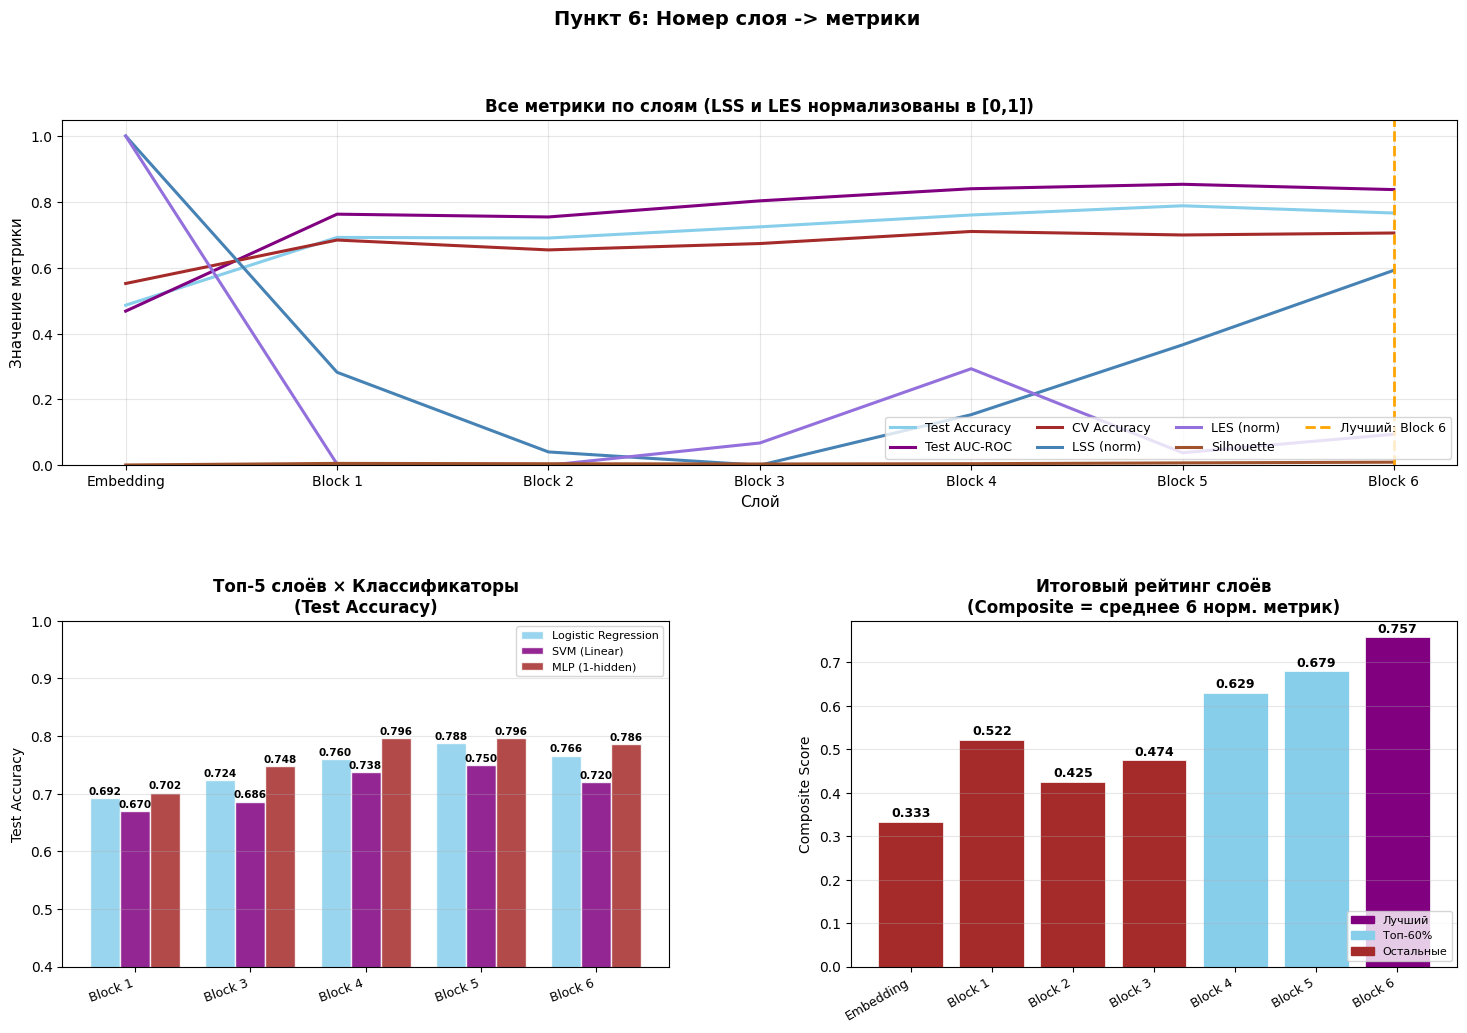

In [23]:
fig = plt.figure(figsize=(18, 11))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.3)
fig.suptitle('Пункт 6: Номер слоя -> метрики', fontsize=14, fontweight='bold')

ax_top = fig.add_subplot(gs[0, :])

metrics_to_plot = {
    'Test Accuracy': ('test_acc',    'skyblue'),
    'Test AUC-ROC':  ('test_auc',    'purple'),
    'CV Accuracy':   ('cv_acc_mean', 'brown'),
    'LSS (norm)':    ('lss',         'steelblue'),
    'LES (norm)':    ('les',         'mediumpurple'),
    'Silhouette':    ('silhouette',  'sienna'),
}

df_plot = df.copy()
df_plot['lss'] = minmax(df_plot['lss'].values)
df_plot['les'] = minmax(df_plot['les'].values)

for label, (col, color) in metrics_to_plot.items():
    ax_top.plot(df_plot['layer_idx'], df_plot[col],
                color=color, lw=2.2, label=label)

best_li = int(df.loc[df['composite'].idxmax(), 'layer_idx'])
ax_top.axvline(best_li, ls='--', color='orange', lw=2,
               label=f'Лучший: {layer_names[best_li]}')

ax_top.set_title('Все метрики по слоям (LSS и LES нормализованы в [0,1])', fontweight='bold')
ax_top.set_xlabel('Слой', fontsize=11)
ax_top.set_ylabel('Значение метрики', fontsize=11)
ax_top.set_xticks(df['layer_idx'])
ax_top.set_xticklabels(layer_lbl, fontsize=10)
ax_top.legend(fontsize=9, ncol=4, loc='lower right')
ax_top.grid(alpha=0.3)
ax_top.set_ylim(0, 1.05)

ax_bl = fig.add_subplot(gs[1, 0])
clfs_list  = df_clf['clf'].unique()
top5_names = [layer_names[i] for i in sorted(top5_indices)]
x = np.arange(len(top5_names))
w  = 0.26
clf_colors = ['skyblue', 'purple', 'brown']

for j, (clf_name, col) in enumerate(zip(clfs_list, clf_colors)):
    sub  = df_clf[df_clf['clf'] == clf_name].sort_values('layer_idx')
    bars = ax_bl.bar(x + j * w, sub['acc'].values, w,
                     label=clf_name, color=col, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, sub['acc'].values):
        ax_bl.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax_bl.set_xticks(x + w)
ax_bl.set_xticklabels(top5_names, rotation=20, ha='right', fontsize=9)
ax_bl.set_ylim(0.4, 1.0)
ax_bl.set_ylabel('Test Accuracy')
ax_bl.set_title('Топ-5 слоёв × Классификаторы\n(Test Accuracy)', fontweight='bold')
ax_bl.legend(fontsize=8)
ax_bl.grid(axis='y', alpha=0.3)

ax_br = fig.add_subplot(gs[1, 1])

bar_colors = ['purple' if v == df['composite'].max() else
              ('skyblue' if v >= df['composite'].quantile(0.6) else 'brown')
              for v in df['composite']]

bars = ax_br.bar(layer_indices, df['composite'],
                 color=bar_colors, edgecolor='white', lw=0.5)
for bar, v in zip(bars, df['composite']):
    ax_br.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
               f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_br.set_xticks(layer_indices)
ax_br.set_xticklabels(layer_lbl, rotation=30, ha='right', fontsize=9)
ax_br.set_ylabel('Composite Score')
ax_br.set_title('Итоговый рейтинг слоёв\n(Composite = среднее 6 норм. метрик)',
                fontweight='bold')
ax_br.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_el = [Patch(color='purple',  label='Лучший'),
             Patch(color='skyblue', label='Топ-60%'),
             Patch(color='brown',   label='Остальные')]
ax_br.legend(handles=legend_el, fontsize=8, loc='lower right')

plt.savefig('final_layer_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
best_li   = int(df.loc[df['composite'].idxmax(), 'layer_idx'])
worst_li  = int(df.loc[df['composite'].idxmin(), 'layer_idx'])
emb_acc   = df.loc[df['layer_idx']==0, 'test_acc'].values[0]
last_acc  = df.loc[df['layer_idx']==n_layers, 'test_acc'].values[0]
best_acc  = df.loc[df['composite'].idxmax(), 'test_acc']
best_auc  = df.loc[df['composite'].idxmax(), 'test_auc']
mid_acc   = df[df['layer_idx'].isin([2,3,4])]['test_acc'].mean()
top3_rows = df.nlargest(3, 'composite')[['layer_name','test_acc','test_auc','composite']]

summary = pd.DataFrame([
    {'Группа':        'Embedding (слой 0)',
     'Test Acc':      round(emb_acc, 4),
     'Описание':      'Только лексика, нет контекста'},
    {'Группа':        'Промежуточные (блоки 2–4)',
     'Test Acc':      round(mid_acc, 4),
     'Описание':      'Пик информативности'},
    {'Группа':        f'Финальный (блок {n_layers})',
     'Test Acc':      round(last_acc, 4),
     'Описание':      'Специализирован под LM'},
    {'Группа':        f'Лучший: {layer_names[best_li]}',
     'Test Acc':      round(best_acc, 4),
     'Описание':      f'AUC = {best_auc:.4f}'},
    {'Группа':        f'Худший: {layer_names[worst_li]}',
     'Test Acc':      round(df.loc[df['composite'].idxmin(), 'test_acc'], 4),
     'Описание':      '—'},
])

print("Таблица 1. Сравнение групп слоёв:")
display(summary.style.format({'Test Acc': '{:.4f}'}).hide(axis='index'))
top3_display = top3_rows.copy()
top3_display.columns = ['Слой', 'Test Acc', 'AUC-ROC', 'Composite']

print("\nТаблица 2. Топ-3 наиболее информативных слоя:")
display(top3_display.style.format({'Test Acc': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Composite': '{:.4f}'}).hide(axis='index'))

Таблица 1. Сравнение групп слоёв:


Группа,Test Acc,Описание
Embedding (слой 0),0.4860,"Только лексика, нет контекста"
Промежуточные (блоки 2–4),0.7247,Пик информативности
Финальный (блок 6),0.7660,Специализирован под LM
Лучший: Block 6,0.7660,AUC = 0.8372
Худший: Embedding,0.4860,—



Таблица 2. Топ-3 наиболее информативных слоя:


Слой,Test Acc,AUC-ROC,Composite
Block 6,0.7660,0.8372,0.7570
Block 5,0.7880,0.8533,0.6787
Block 4,0.7600,0.8398,0.6293


Embedding слой (слой 0) оказался наихудшим — точность 0.486 - практически случайное угадывание (0.5), но это ожидаемо- на этом уровне модель просто переводит слова в числа, никакого понимания контекста или смысла еще нет.


Промежуточные блоки (2–4) заметно лучше — средняя точность 0.725. Здесь модель уже накопила контекстуальную информацию, признаки становятся полезными для задачи классификации тональности.


Финальные блоки (5–6) показали лучший результат. Block 6 — формально лучший по композиции метрик (0.757), но Block 5 лучше его по Test Accuracy (0.788) и AUC-ROC (0.853). Можно сделать вывод о том, что самый последний слой уже начинает думать о следующем токене, а не о смысле предложения — Block 5, на мой взгляд, чуть информативнее для классификации.


Результат: в DistilGPT-2 наиболее полезные для анализа тональности признаки сосредоточены в последних блоках (5–6), а не в промежуточных, как предсказывает гипотеза HiProbe-VAD. Предсказуемо - модель маленькая,Это объясняется тем, что модель маленькая (всего 6 блоков), и глубокой специализации финального слоя под языковое моделирование просто не успевает возникнуть — в отличие от больших моделей типа GPT-2 Large или GPT-3.